In [1]:
# Basic setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Repro / display
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

# ---- Knobs ----
INPUT_CSV   = "SPY.csv"   # your file path
TICKER      = "SPY"
INIT_YEARS  = 4           # initial training length
STEP_MONTHS = 1           # predict 1 calendar month each round
ASSUME_SERIES_IS_VARIANCE = False  # QLIKE is for variance; set False if your RV is volatility (std)

# Optional date bounds (None = use all)
DATA_START = None
DATA_END   = None

_EPS = 1e-12  # for metrics/clipping


In [2]:
def load_rv(input_csv: str) -> pd.Series:
    """Return a daily Series (DatetimeIndex) of RV (float), filtered to QMLE-Trade."""
    df = pd.read_csv(input_csv)
    df = df[["Date", "Volatility", "Type"]].copy()
    df.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    df = df[df["Type"] == "QMLE-Trade"].copy()
    df.drop(columns=["Type"], inplace=True)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    if DATA_START is not None:
        df = df[df.index >= pd.Timestamp(DATA_START)]
    if DATA_END is not None:
        df = df[df.index <= pd.Timestamp(DATA_END)]

    df["RV_daily"] = pd.to_numeric(df["RV_daily"], errors="coerce")
    df = df.dropna(subset=["RV_daily"])
    s = df["RV_daily"].copy()
    s.index.name = "date"
    return s

rv = load_rv(INPUT_CSV)
print(f"{TICKER} RV loaded: {rv.index.min().date()} → {rv.index.max().date()}  (N={len(rv):,})")
rv.head()


SPY RV loaded: 1996-01-02 → 2025-04-29  (N=7,301)


date
1996-01-02    0.140261
1996-01-03    0.082399
1996-01-04    0.211454
1996-01-05    0.022647
1996-01-09    0.228727
Name: RV_daily, dtype: float64

In [3]:
def make_har_design(rv: pd.Series) -> pd.DataFrame:
    """
    HAR(1,5,22) on log1p(RV):
      y_t  = log1p(RV_t)
      x1_t = log1p(RV_{t-1})
      xw_t = log1p(mean(RV_{t-5..t-1}))
      xm_t = log1p(mean(RV_{t-22..t-1}))
    """
    df = pd.DataFrame({"RV": rv})
    df["y"]  = np.log1p(df["RV"])
    df["x1"] = np.log1p(df["RV"].shift(1))
    df["xw"] = np.log1p(df["RV"].rolling(5).mean().shift(1))
    df["xm"] = np.log1p(df["RV"].rolling(22).mean().shift(1))
    df = df.dropna()
    return df

design = make_har_design(rv)
design.head()


,RV,y,x1,xw,xm
date,,,,,
1996-02-02,0.100903,0.096131,0.056991,0.071997,0.099689
1996-02-05,0.103455,0.098446,0.096131,0.079395,0.098068
1996-02-06,0.104815,0.099678,0.098446,0.086491,0.098936
1996-02-07,0.100164,0.095459,0.099678,0.091060,0.094535
1996-02-08,0.094582,0.090373,0.095459,0.089472,0.097736


In [4]:
def month_range_indices(idx: pd.DatetimeIndex, start: pd.Timestamp, months: int = 1) -> pd.DatetimeIndex:
    end = start + pd.DateOffset(months=months)
    return idx[(idx >= start) & (idx < end)]

def qlike_loss(y_true, y_pred, assume_variance=True, eps=_EPS):
    """
    QLIKE(y, f) = y/f - log(y/f) - 1, for positive y, f.
    If your series is volatility (std), set assume_variance=False (squares both).
    """
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    if not assume_variance:
        yt = yt**2
        yp = yp**2
    yt = np.clip(yt, eps, None)
    yp = np.clip(yp, eps, None)
    return float(np.mean(yt/yp - np.log(yt/yp) - 1.0))


In [5]:
def har_expanding_forecast(design: pd.DataFrame,
                           init_years: int = 4,
                           step_months: int = 1) -> pd.DataFrame:
    """
    Re-fit OLS each month using all data strictly before the test month.
    design: DataFrame from make_har_design with columns ['y','x1','xw','xm'].
    Returns DataFrame with columns: date, RV_actual, RV_predicted (raw, non-negative).
    """
    idx_all = design.index
    base_start = idx_all[0]
    test_start = base_start + pd.DateOffset(years=init_years)

    results = []
    cols = ["x1", "xw", "xm"]

    rounds = 0
    while True:
        test_idx = month_range_indices(idx_all, test_start, months=step_months)
        if len(test_idx) == 0:
            break

        # expanding train
        train_idx = idx_all[idx_all < test_start]
        if len(train_idx) < 50:
            test_start += pd.DateOffset(months=step_months)
            continue

        # fit OLS on log-space
        X_tr = sm.add_constant(design.loc[train_idx, cols], has_constant="add")
        y_tr = design.loc[train_idx, "y"]
        model = sm.OLS(y_tr.values, X_tr.values, hasconst=True).fit()

        # predict next month in log-space
        X_te = sm.add_constant(design.loc[test_idx, cols], has_constant="add")
        yhat_log = model.predict(X_te.values)

        # invert to raw RV, clamp >= 0
        yhat = np.maximum(np.expm1(yhat_log), 0.0)

        # actuals (raw)
        y_true = rv.loc[test_idx].values
        y_true = np.maximum(np.where(np.isfinite(y_true), y_true, 0.0), 0.0)

        results.append(pd.DataFrame({
            "date": test_idx,
            "RV_actual": y_true,
            "RV_predicted": yhat
        }))

        rounds += 1
        if rounds % 12 == 0:
            print(f"…completed {rounds} months through {test_idx[-1].date()}")

        # advance month
        next_start = test_start + pd.DateOffset(months=step_months)
        if next_start > idx_all[-1]:
            break
        test_start = next_start

    if not results:
        return pd.DataFrame(columns=["date","RV_actual","RV_predicted"])

    out = pd.concat(results, axis=0).sort_values("date").reset_index(drop=True)
    return out

oos_har = har_expanding_forecast(design, init_years=INIT_YEARS, step_months=STEP_MONTHS)
print(f"OOS rows: {len(oos_har):,}")
oos_har.head()


…completed 12 months through 2001-02-01
…completed 24 months through 2002-02-01
…completed 36 months through 2003-01-31
…completed 48 months through 2004-01-30
…completed 60 months through 2005-02-01
…completed 72 months through 2006-02-01
…completed 84 months through 2007-02-01
…completed 96 months through 2008-02-01
…completed 108 months through 2009-01-30
…completed 120 months through 2010-02-01
…completed 132 months through 2011-02-01
…completed 144 months through 2012-02-01
…completed 156 months through 2013-02-01
…completed 168 months through 2014-01-31
…completed 180 months through 2015-01-30
…completed 192 months through 2016-02-01
…completed 204 months through 2017-02-01
…completed 216 months through 2018-02-01
…completed 228 months through 2019-02-01
…completed 240 months through 2020-01-31
…completed 252 months through 2021-02-01
…completed 264 months through 2022-02-01
…completed 276 months through 2023-02-01
…completed 288 months through 2024-02-01
OOS rows: 6,225


,date,RV_actual,RV_predicted
0,2000-02-02,0.212317,0.183434
1,2000-02-03,0.229693,0.202958
2,2000-02-04,0.167281,0.209503
3,2000-02-07,0.120758,0.178931
4,2000-02-08,0.109395,0.154141


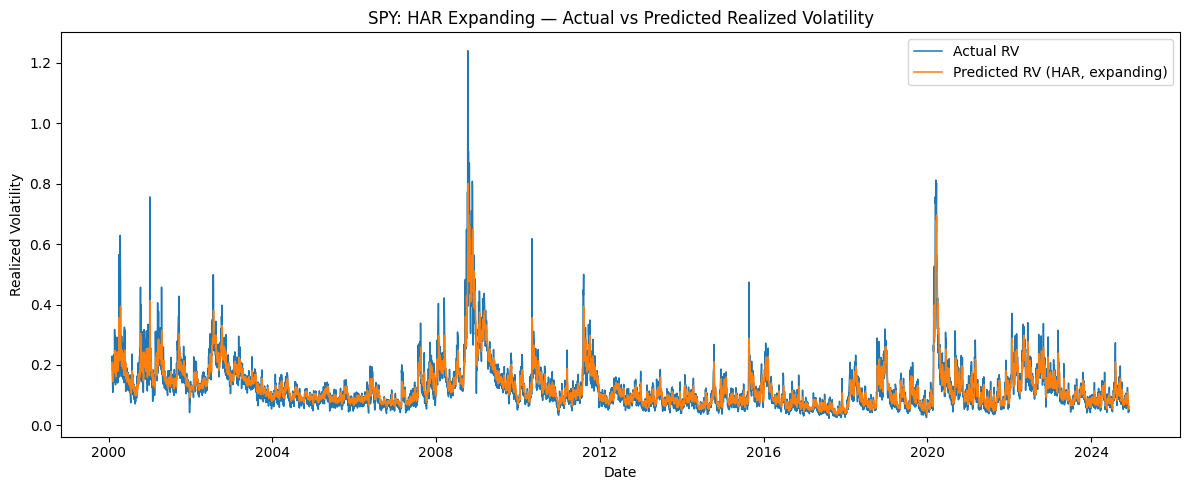

In [6]:
plt.figure(figsize=(12,5))
plt.plot(oos_har["date"], oos_har["RV_actual"],    label="Actual RV", linewidth=1.1)
plt.plot(oos_har["date"], oos_har["RV_predicted"], label="Predicted RV (HAR, expanding)", linewidth=1.1)
plt.title(f"{TICKER}: HAR Expanding — Actual vs Predicted Realized Volatility")
plt.xlabel("Date"); plt.ylabel("Realized Volatility"); plt.legend(); plt.tight_layout(); plt.show()


In [7]:
y_true = np.clip(oos_har["RV_actual"].to_numpy(float), _EPS, None)
y_pred = np.clip(oos_har["RV_predicted"].to_numpy(float), _EPS, None)

mse   = float(np.mean((y_true - y_pred)**2))
qlike = qlike_loss(y_true, y_pred, assume_variance=ASSUME_SERIES_IS_VARIANCE)

# R^2 vs. mean benchmark on OOS segment (optional)
ybar  = float(np.mean(y_true))
tss   = float(np.sum((y_true - ybar)**2))
sse   = float(np.sum((y_true - y_pred)**2))
r2    = float(1.0 - sse/tss) if tss > 0 else np.nan

print(f"OOS [{TICKER}]  MSE = {mse:.6g} | QLIKE = {qlike:.6g} | R^2 = {r2:.4f} | N = {len(y_true)}")


OOS [SPY]  MSE = 0.00150433 | QLIKE = 0.120228 | R^2 = 0.7859 | N = 6225
